#### Replication of the TimeView Model in ShapeU Machinery on Simulated Tumour Data

This implementation runs on data:
- with no unobserved heteroegeneity in the DGP,
- with no observational noise, 
- with equally spaced observations for all individuals. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)   # matches Batch/Normaliser's float64 tensors

from pathlib import Path
import sys

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

# Functions needed for data generation, training and plotting
from scripts.shape_uncertainty.simulated_data.data_generator import make_data_splits
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary
from scripts.shape_uncertainty.analysis.plot_helpers import plot_individual_diagnostic
from scripts.shape_uncertainty.model.model_training import Tuner

from scripts.shape_uncertainty.analysis.utilities import save_run
from scripts.shape_uncertainty.analysis.utilities import load_run
from scripts.shape_uncertainty.model.model_inference import InferenceEngine

# Functions needed for model evaluation / shape extraction
from scripts.shape_uncertainty.model.model_evaluation import ExtractionEvaluator
from scripts.shape_uncertainty.model.model_evaluation import  ModelEvaluator
from scripts.shape_uncertainty.model.model import MeanOnlyModel

In [2]:
# Key constants
NR_OBS = 20
NR_INTERIOR_KNOTS = 5 # B = 9 matches TIMEVIEW 
T = 1.0

SIGMA = 0.0 # no observation noise
ALPHA_G, ALPHA_D = 0.0, 0.0 # no unobserved heterogeneity

In [3]:
# Specify the configuration for the data generation 
simulation_config = dict(D=2000, 
                         N=NR_OBS, 
                         hyperparams={"g0": 2.0, "d0": 180.0, "rho0": 10.0, "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}, 
                         sigma=SIGMA, # Variance for the observation noise
                         ranges=None, # covariate ranges
                         T=T, 
                         regular=True, # equally spaced observations
                         include_endpoints=True, # ignored when regular=True
)

# Create training, validation and test datasets
train, val, test = make_data_splits(simulation_config, seed=42)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 2000 2000 - sigma: 0.0


In [4]:
# Built a dictionary with the key spline objects for a given knot configuration.
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)

#### Train MeanOnlyModel at lambda_mean=0.0

In [5]:
# Train a MeanOnlyModel with lambda_mean=0.0 
# Like TimeView we use 100 Optima trials, 200 epochs, patience 10
tuner = Tuner(
    train_dataset=train,
    val_dataset=val,
    basis_functions=knot_objects["basis_functions"],
    Omega=knot_objects["Omega"],
    nr_basis=knot_objects["nr_basis"],
    lambda_mean=0.0,
    lambda_re=0.0,
    nr_epochs=200,
    model_cls=MeanOnlyModel,
    model_kwargs={},
    patience=10,
)
tuned = tuner.run(nr_trials=100)

# Save the trained model
knot_config = {"nr_interior_knots": NR_INTERIOR_KNOTS, "T": T}
save_run(tuned, knot_config, generate_config=simulation_config, lambda_mean=0.0, path="timeview_replication")

[I 2026-07-16 13:52:40,777] A new study created in memory with name: no-name-4fefed9c-2838-4d84-9667-2f0188d45d86
[I 2026-07-16 13:52:43,472] Trial 0 finished with value: 0.5962131648020813 and parameters: {'hidden_0': 40, 'hidden_1': 94, 'hidden_2': 82, 'activation': 'elu', 'dropout': 0.25545715258540047, 'lr': 0.0009595782495510631, 'batch_size': 128, 'weight_decay': 0.0064722886717809396}. Best is trial 0 with value: 0.5962131648020813.
[I 2026-07-16 13:52:44,390] Trial 1 finished with value: 0.6547325019429816 and parameters: {'hidden_0': 52, 'hidden_1': 105, 'hidden_2': 113, 'activation': 'relu', 'dropout': 0.047966213052640594, 'lr': 0.0015534229592960476, 'batch_size': 128, 'weight_decay': 0.06434423560619948}. Best is trial 0 with value: 0.5962131648020813.
[I 2026-07-16 13:52:51,217] Trial 2 finished with value: 0.5823719280776561 and parameters: {'hidden_0': 123, 'hidden_1': 59, 'hidden_2': 91, 'activation': 'tanh', 'dropout': 0.1781449694154959, 'lr': 0.00024362769751097447,

In [6]:
# Load the saved MeanOnlyModel
loaded = load_run(path="timeview_replication", model_cls=MeanOnlyModel)

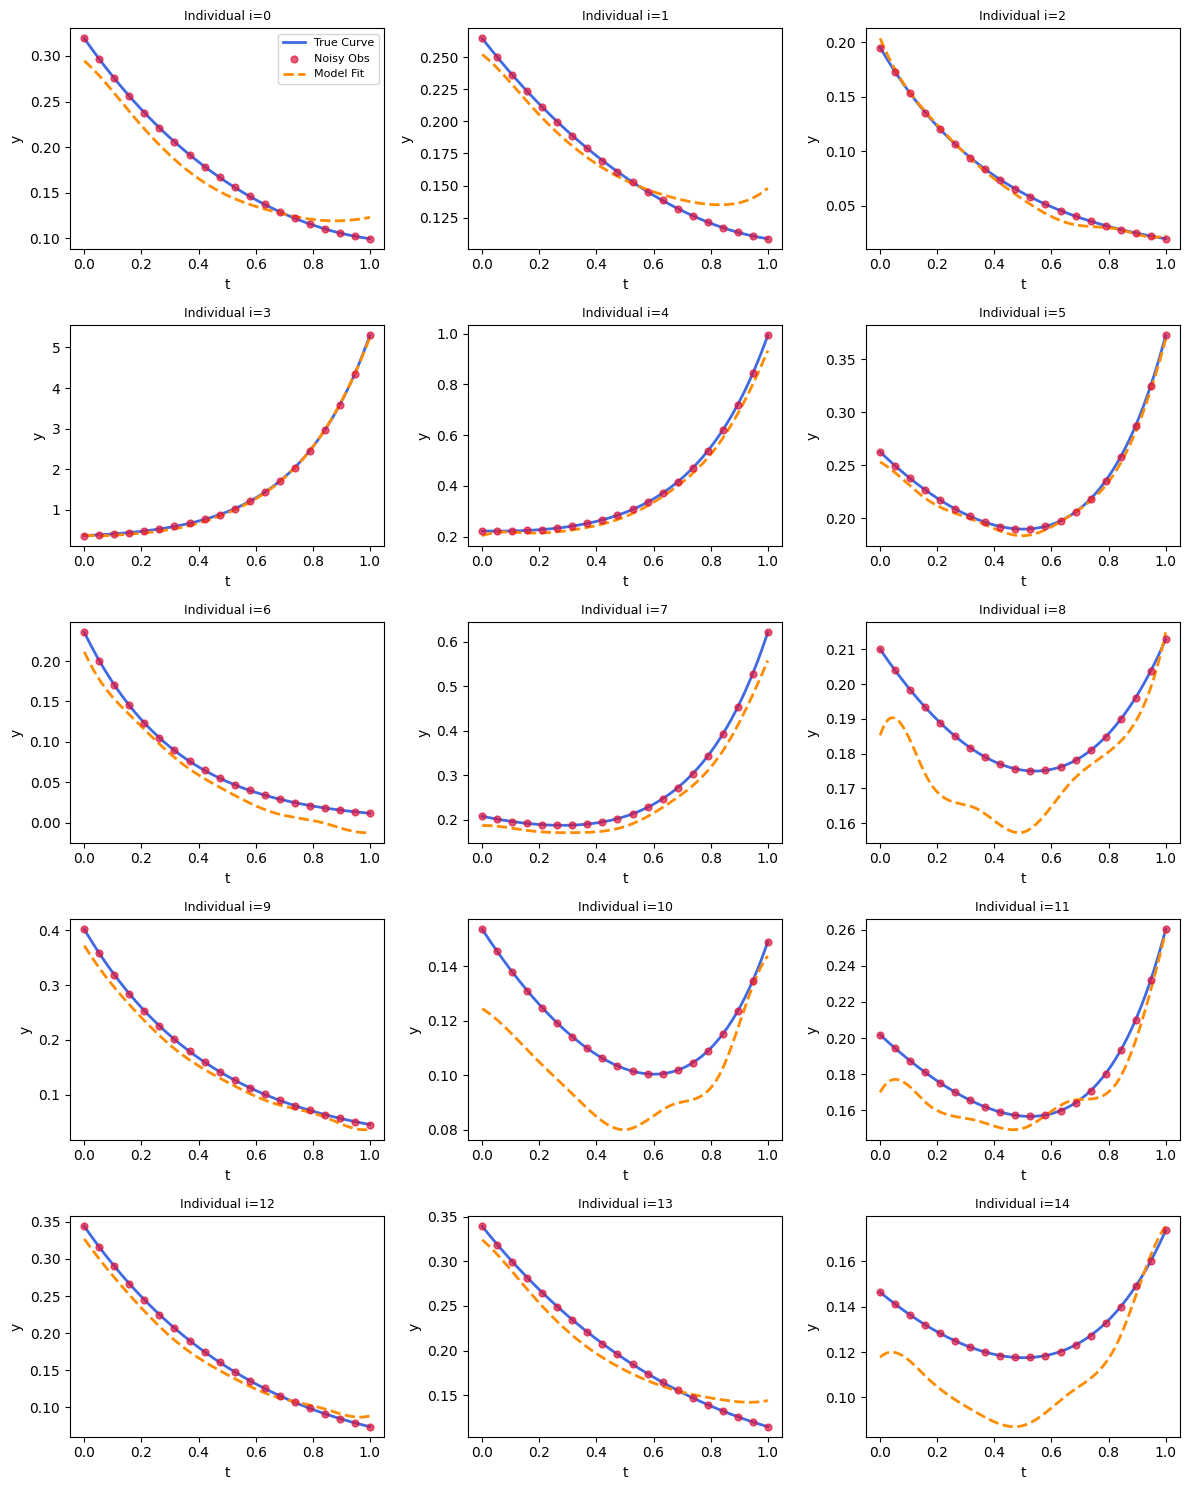

In [7]:
# Plot observations
target_patients = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

plotting_engine = InferenceEngine()
plotting_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
)

fig = plot_individual_diagnostic(
    dataset=test, 
    indices=target_patients, 
    inference_engine=plotting_engine,
    show_true=True, 
    show_noisy=True, 
    show_estimated=True,
)
plt.show()

In [8]:
# Compute value-space accuracy on the test set
evaluator = ModelEvaluator(inference_engine=plotting_engine, test_dataset=test)
evaluation_times = np.linspace(0.0, test.T, 200)
value_metrics = evaluator.compute_value_space_accuracy(evaluation_times)
print(f"Value-space RMSE: {value_metrics['rmse']:.4f}")
print(f"Value-space R^2:  {value_metrics['r2']:.4f}")


Value-space RMSE: 0.0232
Value-space R^2:  0.9975


#### Predict shape summaries with the naiive shape extration algorithm

In [9]:
# Timeview shape extraction
ZETA_REL = 0.0
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
UPSILON_PRUNE_REL, DO_PRUNE = 0.0, False

# Initialise an inference engine for analysis
naive_engine = InferenceEngine()
naive_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
    do_prune=DO_PRUNE
)

In [10]:
# Step 1: Create a model evaluator for the test dataset and get shape summaries 
evaluator = ModelEvaluator(naive_engine, test)
predicted_summaries = evaluator.get_shape_summary_estimates()

# Step 2: Get the analytically-derived ground-truth from the data generating process
extraction_evaluator = ExtractionEvaluator(test)
true_summaries = extraction_evaluator.get_true_shape_summary(UPSILON_1_REL, UPSILON_2_REL)

# Step 3: Print table of shape summaries
def _shape_states(summary):
    return [state for state, _ in summary]

df_shapes = pd.DataFrame({
    "patient": target_patients,
    "true_summary": [_shape_states(true_summaries[i]) for i in target_patients],
    "predicted_summary": [_shape_states(predicted_summaries[i]) for i in target_patients],
})
display(df_shapes)

# Step 4: Print table of transition time points
def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

df_transition_times = pd.DataFrame({
    "patient": target_patients,
    "true_transition_times": [_transition_times(true_summaries[i]) for i in target_patients],
    "predicted_transition_times": [_transition_times(predicted_summaries[i]) for i in target_patients],
})

display(df_transition_times)

# Compute shape extraction accuracy on the test set
accuracy = extraction_evaluator.exact_sequence_match(predicted_summaries, true_summaries)
print(f"Exact state-sequence match accuracy: {accuracy:.1%}")


,patient,true_summary,predicted_summary
0,0,[convex_decreasing],"[concave_decreasing, convex_decreasing, convex..."
1,1,[convex_decreasing],"[concave_decreasing, convex_decreasing, convex..."
2,2,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex..."
3,3,[convex_increasing],"[convex_decreasing, convex_increasing]"
4,4,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
5,5,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, concav..."
6,6,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex..."
7,7,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
8,8,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
9,9,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex..."


,patient,true_transition_times,predicted_transition_times
0,0,[0.0000],"[0.0000, 0.1292, 0.8750]"
1,1,[0.0000],"[0.0000, 0.1271, 0.8322]"
2,2,[0.0000],"[0.0000, 0.7549, 0.8784, 0.9612]"
3,3,[0.0000],"[0.0000, 0.0534]"
4,4,"[0.0000, 0.0479]","[0.0000, 0.0843, 0.1327, 0.1849]"
5,5,"[0.0000, 0.5015]","[0.0000, 0.0924, 0.2871, 0.3717, 0.4972]"
6,6,[0.0000],"[0.0000, 0.1602, 0.1958, 0.7572, 0.8780, 0.9858]"
7,7,"[0.0000, 0.2790]","[0.0000, 0.0068, 0.1159, 0.2952]"
8,8,"[0.0000, 0.5419]","[0.0000, 0.0436, 0.1270, 0.2865, 0.3926, 0.486..."
9,9,[0.0000],"[0.0000, 0.7396, 0.8740, 0.9801]"


Exact state-sequence match accuracy: 3.4%


#### Predict shape summaries with the shape extration algorithm with pruning

In [11]:
# Shape extraction with pruning
ZETA_REL = 0.000001
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
UPSILON_PRUNE_REL, DO_PRUNE = 0.06, True

# Initialise an inference engine for analysis
pruning_engine = InferenceEngine()
pruning_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
    do_prune=DO_PRUNE
)

In [12]:
# Step 1: Create a model evaluator for the test dataset and get shape summaries 
evaluator = ModelEvaluator(pruning_engine, test)
predicted_summaries = evaluator.get_shape_summary_estimates()

# Step 2: Get the analytically-derived ground-truth from the data generating process
extraction_evaluator = ExtractionEvaluator(test)
true_summaries = extraction_evaluator.get_true_shape_summary(UPSILON_1_REL, UPSILON_2_REL)

# Step 3: Print table of shape summaries
def _shape_states(summary):
    return [state for state, _ in summary]

df_shapes = pd.DataFrame({
    "patient": target_patients,
    "true_summary": [_shape_states(true_summaries[i]) for i in target_patients],
    "predicted_summary": [_shape_states(predicted_summaries[i]) for i in target_patients],
})
display(df_shapes)

# Step 4: Print table of transition time points
def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

df_transition_times = pd.DataFrame({
    "patient": target_patients,
    "true_transition_times": [_transition_times(true_summaries[i]) for i in target_patients],
    "predicted_transition_times": [_transition_times(predicted_summaries[i]) for i in target_patients],
})

display(df_transition_times)

# Compute shape extraction accuracy on the test set
accuracy = extraction_evaluator.exact_sequence_match(predicted_summaries, true_summaries)
print(f"Exact state-sequence match accuracy: {accuracy:.1%}")


,patient,true_summary,predicted_summary
0,0,[convex_decreasing],[convex_decreasing]
1,1,[convex_decreasing],"[convex_decreasing, convex_increasing]"
2,2,[convex_decreasing],[convex_decreasing]
3,3,[convex_increasing],[convex_increasing]
4,4,"[convex_decreasing, convex_increasing]",[convex_increasing]
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
6,6,[convex_decreasing],[convex_decreasing]
7,7,"[convex_decreasing, convex_increasing]",[convex_increasing]
8,8,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
9,9,[convex_decreasing],[convex_decreasing]


,patient,true_transition_times,predicted_transition_times
0,0,[0.0000],[0.0000]
1,1,[0.0000],"[0.0000, 0.8322]"
2,2,[0.0000],[0.0000]
3,3,[0.0000],[0.0000]
4,4,"[0.0000, 0.0479]",[0.0000]
5,5,"[0.0000, 0.5015]","[0.0000, 0.4972]"
6,6,[0.0000],[0.0000]
7,7,"[0.0000, 0.2790]",[0.0000]
8,8,"[0.0000, 0.5419]","[0.0000, 0.0436, 0.1270, 0.4862]"
9,9,[0.0000],[0.0000]


Exact state-sequence match accuracy: 80.7%
